# 04 - Portfolio Optimization

## Goal

Optimize loan-limit increase allocation under constraints, and compare:
- `lp_relax`
- `lp_round` (integerized LP)
- `greedy`

Scenarios: `base`, `stress`, `benign`.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

ROOT = Path().cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

from optimizer import run_all_scenarios, plot_strategy_kpis

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df = pd.read_csv(ROOT / 'data' / 'df_demand.csv')
if 'max_possible_increases' not in df.columns:
    df['max_possible_increases'] = 1
if 'ead' not in df.columns:
    df['ead'] = df['initial_loan']

print(f'Loaded: {df.shape}')

Loaded: (30000, 19)


---
## 1. Objective and Constraints

Decision variable: `x_i` = number of offered increases for customer `i`.

Objective (expected, risk-adjusted, discounted):

`max sum_i x_i * p_accept_i * ev_per_increase_i * discount_factor`

Constraints:
- `0 <= x_i <= eligible_i * max_possible_increases_i`
- Portfolio capital: `sum_i x_i * p_accept_i * ead_i <= capital_limit_ratio * total_initial_loan`

In [2]:
CAPITAL_LIMIT_RATIO = 0.30
SCENARIOS = ['base', 'stress', 'benign']
summary, plans = run_all_scenarios(df, scenarios=SCENARIOS, capital_limit_ratio=CAPITAL_LIMIT_RATIO)
summary

,scenario,strategy,expected_npv,capital_used,capital_limit,capital_usage_pct,offered_increases,offered_customers,mix_prime,mix_near,mix_sub
0,base,lp_relax,322501.045499,2.477279e+07,24772793.4,1.000000,18769.011239,18770,0.334008,0.552347,0.113645
1,base,lp_round,322500.908305,2.477277e+07,24772793.4,0.999999,18769.000000,18769,0.334008,0.552347,0.113645
2,base,greedy,322500.908305,2.477277e+07,24772793.4,0.999999,18769.000000,18769,0.334008,0.552347,0.113645
3,stress,lp_relax,285586.936690,2.477279e+07,24772793.4,1.000000,21038.304730,21039,0.297980,0.588560,0.113460
4,stress,lp_round,285584.336537,2.477213e+07,24772793.4,0.999973,21038.000000,21038,0.297985,0.588554,0.113461
5,stress,greedy,285584.336537,2.477213e+07,24772793.4,0.999973,21038.000000,21038,0.297985,0.588554,0.113461
6,benign,lp_relax,341400.478660,2.477279e+07,24772793.4,1.000000,17684.646559,17685,0.354488,0.531967,0.113545
7,benign,lp_round,341399.070151,2.477256e+07,24772793.4,0.999991,17685.000000,17685,0.354481,0.531920,0.113599
8,benign,greedy,341399.070151,2.477256e+07,24772793.4,0.999991,17685.000000,17685,0.354481,0.531920,0.113599


---
## 2. Strategy Comparison

Compare expected NPV, capital usage, offered increases, and segment mix.

,scenario,strategy,expected_npv,capital_used,capital_limit,capital_usage_pct,offered_increases,offered_customers,mix_prime,mix_near,mix_sub
0,base,lp_relax,322501.0455,2.477279e+07,24772793.4,1.0,18769.0112,18770,0.3340,0.5523,0.1136
1,base,lp_round,322500.9083,2.477277e+07,24772793.4,1.0,18769.0000,18769,0.3340,0.5523,0.1136
2,base,greedy,322500.9083,2.477277e+07,24772793.4,1.0,18769.0000,18769,0.3340,0.5523,0.1136
6,benign,lp_relax,341400.4787,2.477279e+07,24772793.4,1.0,17684.6466,17685,0.3545,0.5320,0.1135
7,benign,lp_round,341399.0702,2.477256e+07,24772793.4,1.0,17685.0000,17685,0.3545,0.5319,0.1136
8,benign,greedy,341399.0702,2.477256e+07,24772793.4,1.0,17685.0000,17685,0.3545,0.5319,0.1136
3,stress,lp_relax,285586.9367,2.477279e+07,24772793.4,1.0,21038.3047,21039,0.2980,0.5886,0.1135
4,stress,lp_round,285584.3365,2.477213e+07,24772793.4,1.0,21038.0000,21038,0.2980,0.5886,0.1135
5,stress,greedy,285584.3365,2.477213e+07,24772793.4,1.0,21038.0000,21038,0.2980,0.5886,0.1135


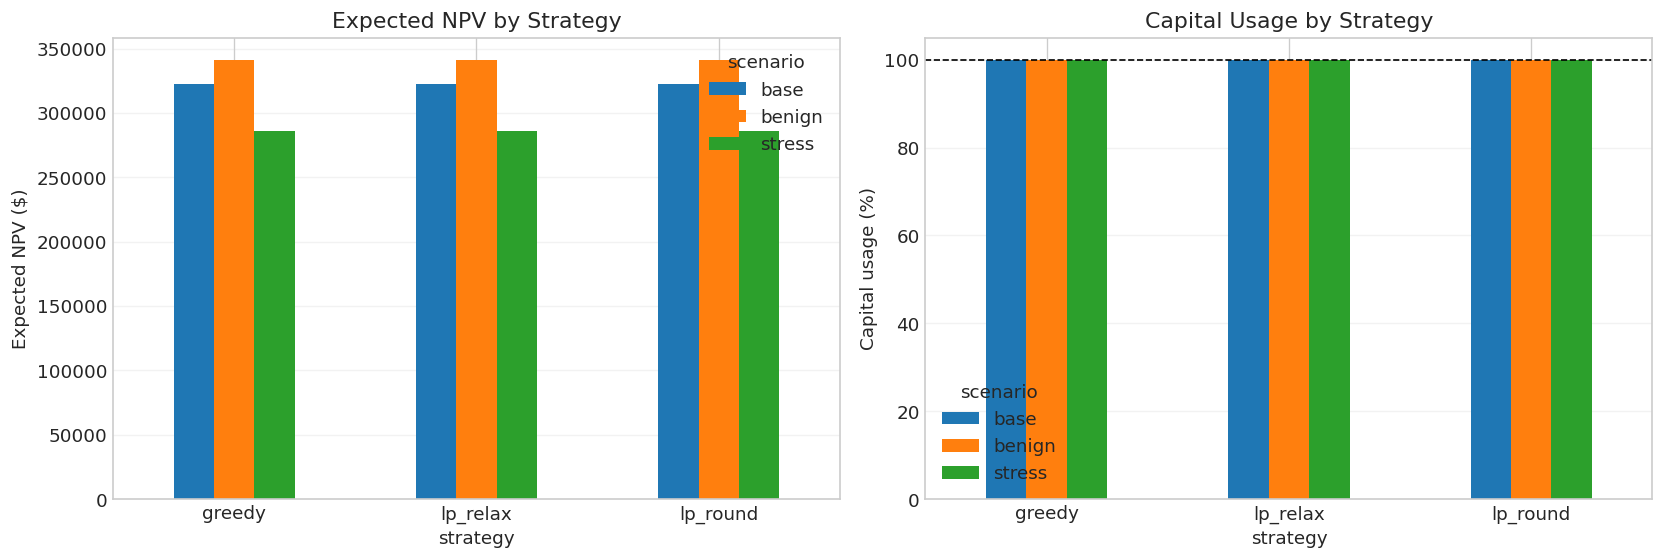

In [3]:
display(summary.sort_values(['scenario', 'expected_npv'], ascending=[True, False]).round(4))
plot_strategy_kpis(summary)

---
## 3. Sanity Checks

Validate core optimization invariants:
- capital usage <= 100%
- no negative offers
- LP-relax expected NPV should be upper bound vs integer heuristics

In [4]:
assert (summary['capital_usage_pct'] <= 1.0000001).all(), 'Capital exceeded'
assert (summary['offered_increases'] >= 0).all(), 'Negative offers'

check = []
for sc, g in summary.groupby('scenario'):
    lp = g.loc[g['strategy'] == 'lp_relax', 'expected_npv'].iloc[0]
    mx = g.loc[g['strategy'].isin(['lp_round', 'greedy']), 'expected_npv'].max()
    check.append({'scenario': sc, 'lp_relax_npv': lp, 'best_integer_npv': mx, 'gap': lp - mx})

check_df = pd.DataFrame(check)
display(check_df.round(4))

,scenario,lp_relax_npv,best_integer_npv,gap
0,base,322501.0455,322500.9083,0.1372
1,benign,341400.4787,341399.0702,1.4085
2,stress,285586.9367,285584.3365,2.6002


---
## 4. KPI View by Scenario

We summarize KPI deltas for decision-making in the final recommendation.

In [5]:
kpi = summary[['scenario', 'strategy', 'expected_npv', 'capital_usage_pct', 'offered_increases', 'offered_customers', 'mix_prime', 'mix_near', 'mix_sub']].copy()
for c in ['capital_usage_pct', 'mix_prime', 'mix_near', 'mix_sub']:
    kpi[c] = kpi[c] * 100

display(kpi.round(2))

,scenario,strategy,expected_npv,capital_usage_pct,offered_increases,offered_customers,mix_prime,mix_near,mix_sub
0,base,lp_relax,322501.05,100.0,18769.01,18770,33.40,55.23,11.36
1,base,lp_round,322500.91,100.0,18769.00,18769,33.40,55.23,11.36
2,base,greedy,322500.91,100.0,18769.00,18769,33.40,55.23,11.36
3,stress,lp_relax,285586.94,100.0,21038.30,21039,29.80,58.86,11.35
4,stress,lp_round,285584.34,100.0,21038.00,21038,29.80,58.86,11.35
5,stress,greedy,285584.34,100.0,21038.00,21038,29.80,58.86,11.35
6,benign,lp_relax,341400.48,100.0,17684.65,17685,35.45,53.20,11.35
7,benign,lp_round,341399.07,100.0,17685.00,17685,35.45,53.19,11.36
8,benign,greedy,341399.07,100.0,17685.00,17685,35.45,53.19,11.36


---
## 5. Export

Export optimization summary and recommended integer plan (`lp_round`) for Notebook 05 simulation.

In [6]:
summary_out = ROOT / 'data' / 'optimization_summary.csv'
summary.to_csv(summary_out, index=False)

# Build recommendation table from lp_round per scenario
rec_parts = []
for sc in SCENARIOS:
    x = plans[sc]['lp_round']
    tmp = df[['customer_id', 'risk_label', 'eligible', 'max_possible_increases']].copy()
    tmp['scenario'] = sc
    tmp['x_recommended'] = x.values
    rec_parts.append(tmp)
rec = pd.concat(rec_parts, ignore_index=True)

rec_out = ROOT / 'data' / 'allocation_recommended.csv'
rec.to_csv(rec_out, index=False)

print(f'Saved: {summary_out}')
print(f'Saved: {rec_out}')
print(f'Recommendation shape: {rec.shape}')

Saved: /data/aturov/loan_limit_increases/data/optimization_summary.csv
Saved: /data/aturov/loan_limit_increases/data/allocation_recommended.csv
Recommendation shape: (90000, 6)
